# EDA

## Imports

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder
from sklearn.compose import ColumnTransformer
from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, recall_score, f1_score, classification_report


In [2]:
data = pd.read_csv('/Users/ashay/Desktop/DREXEL/SPRING 26/DSCI_631/project/sleep_health_dataset.csv')

data.head()

,person_id,age,gender,occupation,bmi,country,sleep_duration_hrs,sleep_quality_score,rem_percentage,deep_sleep_percentage,...,heart_rate_resting_bpm,sleep_aid_used,shift_work,room_temperature_celsius,weekend_sleep_diff_hrs,season,day_type,cognitive_performance_score,sleep_disorder_risk,felt_rested
0,1,29,Female,Driver,25.7,Japan,6.19,6.6,22.5,19.3,...,63,0,0,20.1,1.84,Autumn,Weekday,73.4,Healthy,0
1,2,55,Female,Software Engineer,22.0,USA,8.32,6.9,26.9,14.9,...,52,1,0,18.0,0.13,Winter,Weekend,99.4,Healthy,1
2,3,42,Male,Nurse,25.0,India,3.74,1.0,20.2,16.2,...,72,0,1,17.9,1.67,Spring,Weekend,2.5,Severe,0
3,4,37,Female,Student,29.5,India,6.79,6.4,17.7,17.7,...,71,0,0,19.1,2.37,Summer,Weekend,67.8,Healthy,0
4,5,23,Male,Lawyer,23.6,Spain,5.02,3.2,23.3,18.3,...,71,0,0,19.7,1.26,Summer,Weekday,38.1,Mild,0


## Variables:
**Target Variables:** cognitive_performance_score, sleep_disorder_risk

**Continuous Variables:** age, bmi, sleep_duration_hrs, sleep_quality_score, rem_percentage, deep_sleep_percentage, sleep_latency_mins, wake_episodes_per_night, caffeine_mg_before_bed, alcohol_units_before_bed, screen_time_before_bed_mins, exercise_day, steps_that_day, nap_duration_mins, stress_score, work_hours_that_day, heart_rate_resting_bpm, room_temperature_celsius, weekend_sleep_diff_hrs

**Categorical Variables:** gender, occupation, country, chronotype, mental_health_condition, sleep_aid_used, shift_work, season, day_type


## Target Variable Distribution

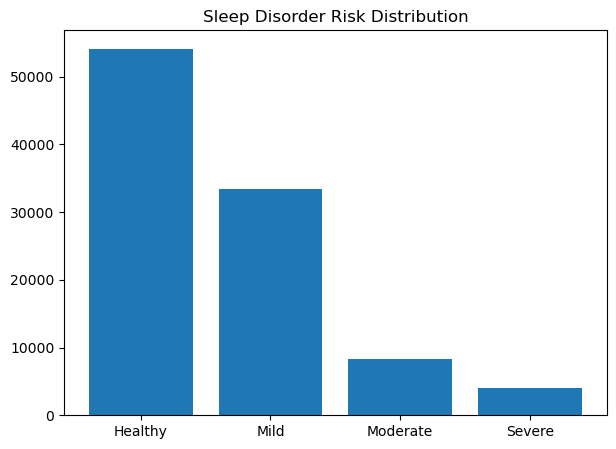

In [18]:
disorder = ['Healthy', 'Mild', 'Moderate', 'Severe']
counts = data['sleep_disorder_risk'].value_counts()[disorder]

fig, ax = plt.subplots(figsize=(7,5))
ax.bar(disorder, counts)
ax.set_title('Sleep Disorder Risk Distribution')
plt.show()

Significant class imbalance with Healthy and Mild dominating and Moderate and Severe being minority classes at 8% and 4% respectively.

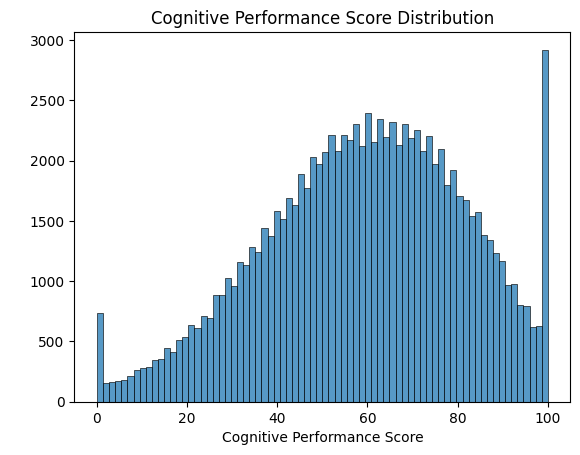

In [4]:
sns.histplot(data['cognitive_performance_score'])
plt.title("Cognitive Performance Score Distribution")
plt.xlabel("Cognitive Performance Score")
plt.ylabel(" ")
plt.show()

Approximately normally distributed between 20-90, centered around 50-65. Notable spikes at 0 and 100 suggest ceiling and floor effects from the synthetic data generation process.

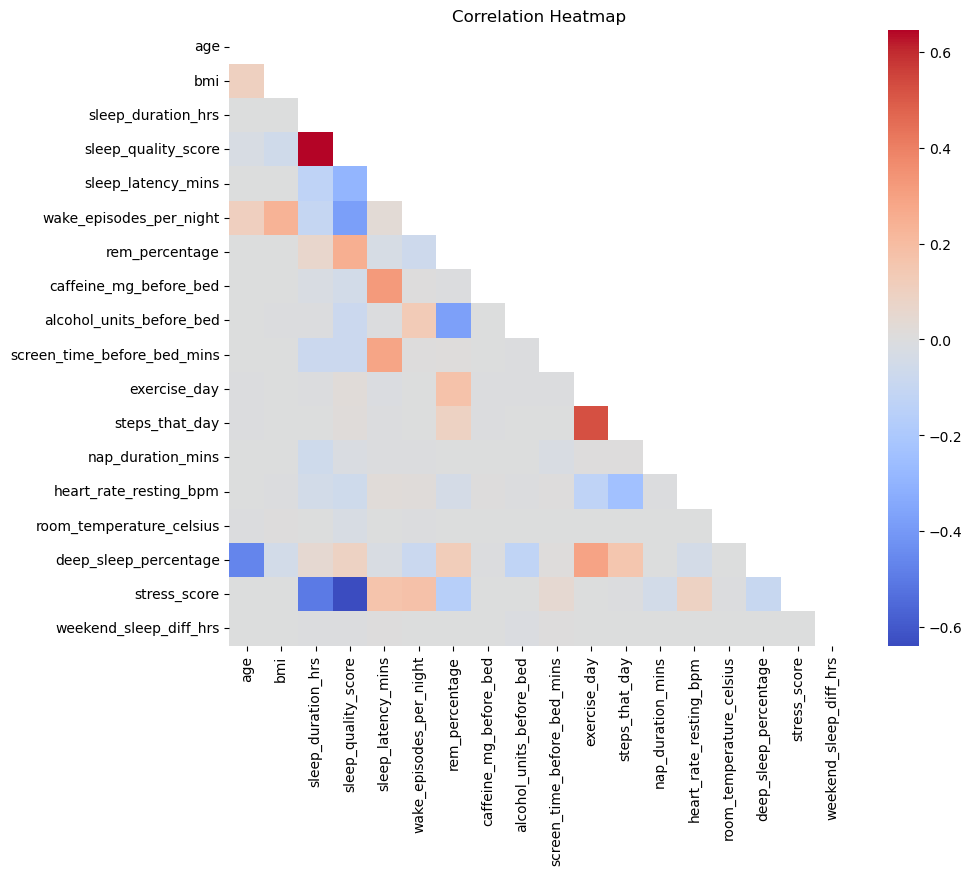

In [20]:
num_cols = ['age', 'bmi', 'sleep_duration_hrs', 'sleep_quality_score', 'sleep_latency_mins', 'wake_episodes_per_night', 
            'rem_percentage', 'caffeine_mg_before_bed', 'alcohol_units_before_bed', 'screen_time_before_bed_mins', 
            'exercise_day', 'steps_that_day', 'nap_duration_mins', 'heart_rate_resting_bpm', 'room_temperature_celsius',
            'deep_sleep_percentage', 'stress_score', 'weekend_sleep_diff_hrs']

corr = data[num_cols].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(corr, mask=mask, ax=ax, cmap='coolwarm')
ax.set_title('Correlation Heatmap')
plt.show()

The heatmap reveals that sleep duration and quality are strongly positively correlated, stress negatively impacts both, and deep sleep percentage decreases with age, while most other feature pairs show weak or no correlation.

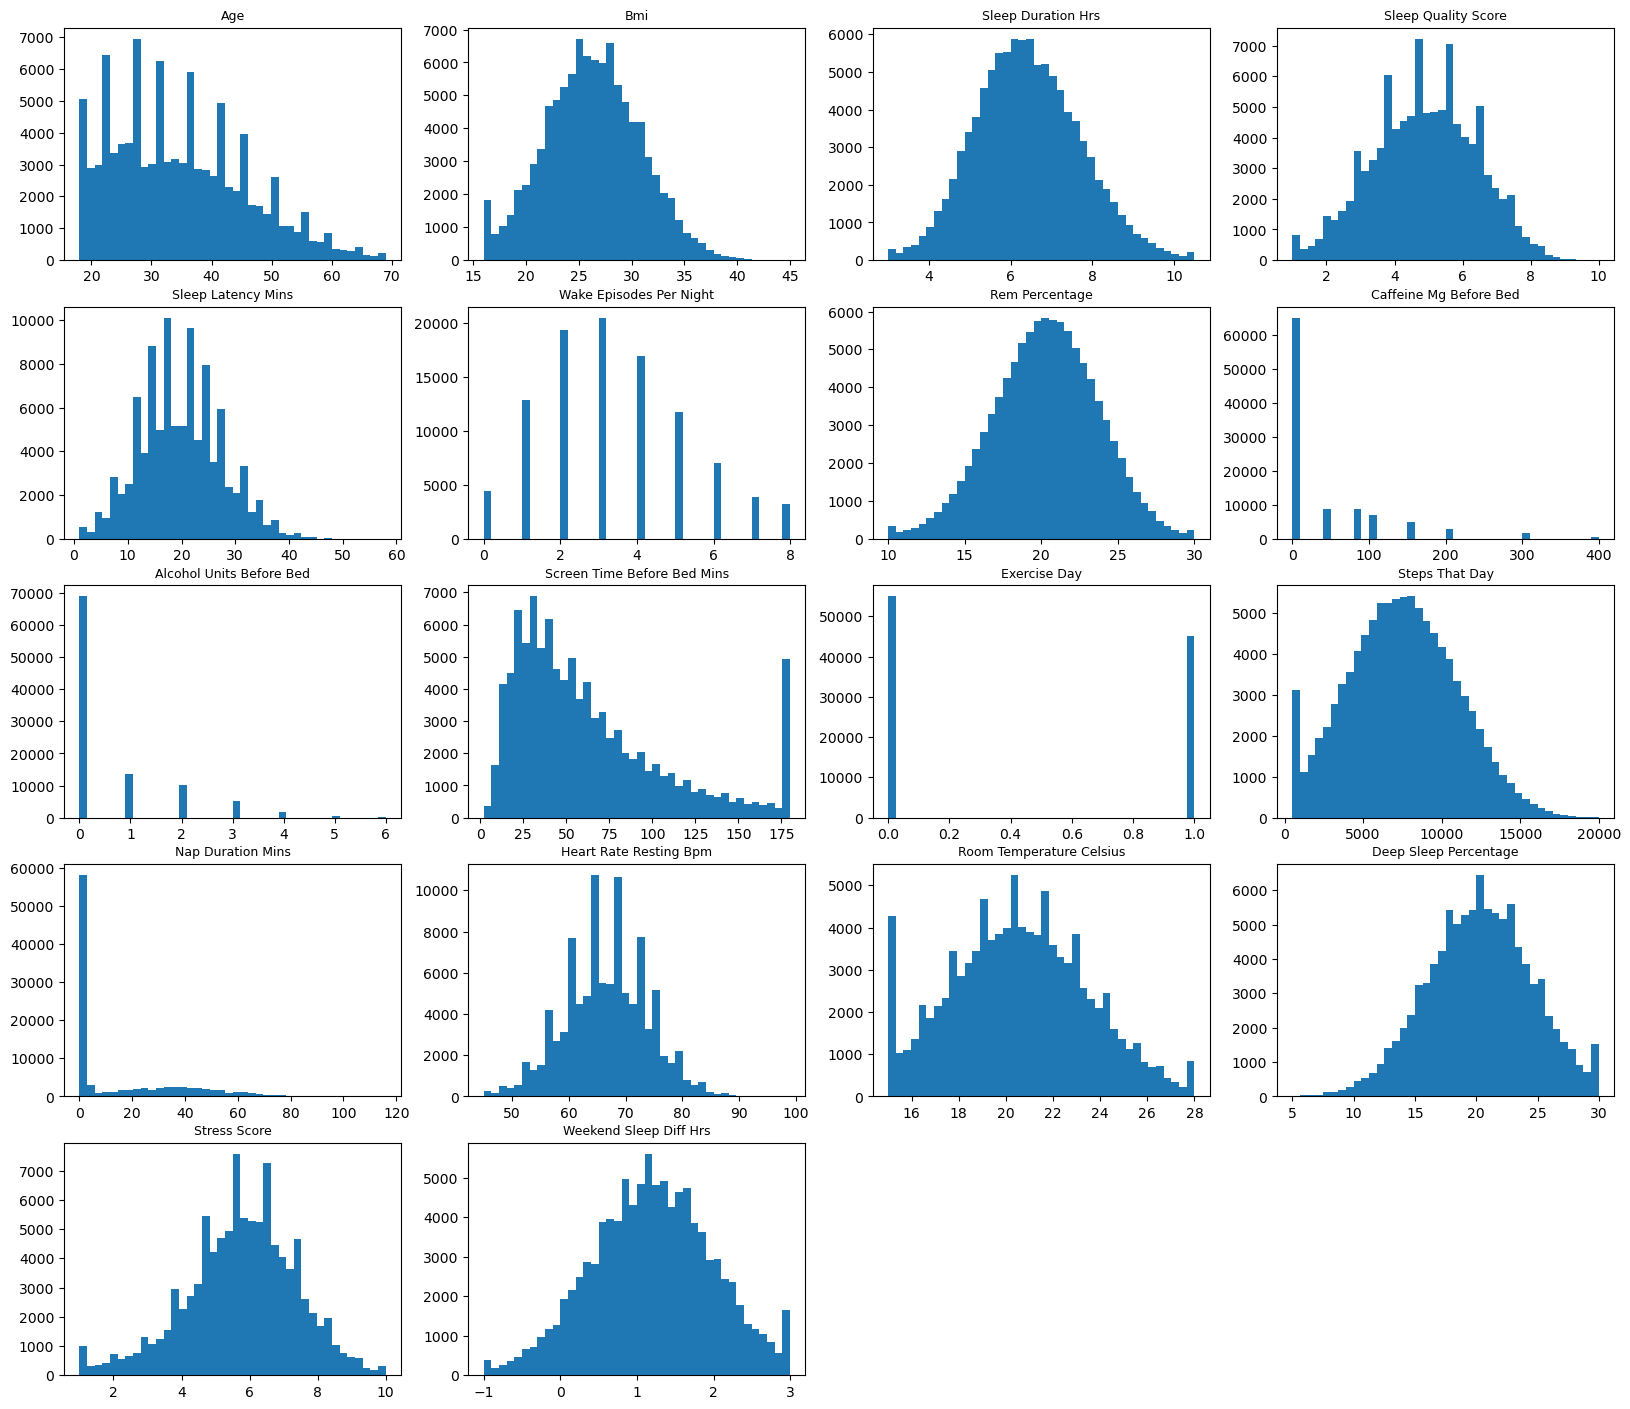

In [21]:
n_cols = 4
n_rows = int(np.ceil(len(num_cols) / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, n_rows * 3.5))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    axes[i].hist(data[col], bins=40)
    axes[i].set_title(col.replace('_', ' ').title(), fontsize=9)
    axes[i].set_xlabel('')

for j in range(len(num_cols), len(axes)):
    axes[j].set_visible(False)


plt.show()

Most features are approximately normally distributed, however age and caffeine are right skewed, sleep quality score and heart rate show bimodal distributions, stress score is multimodal, and caffeine, alcohol, and nap duration are heavily right skewed with most individuals recording zero.

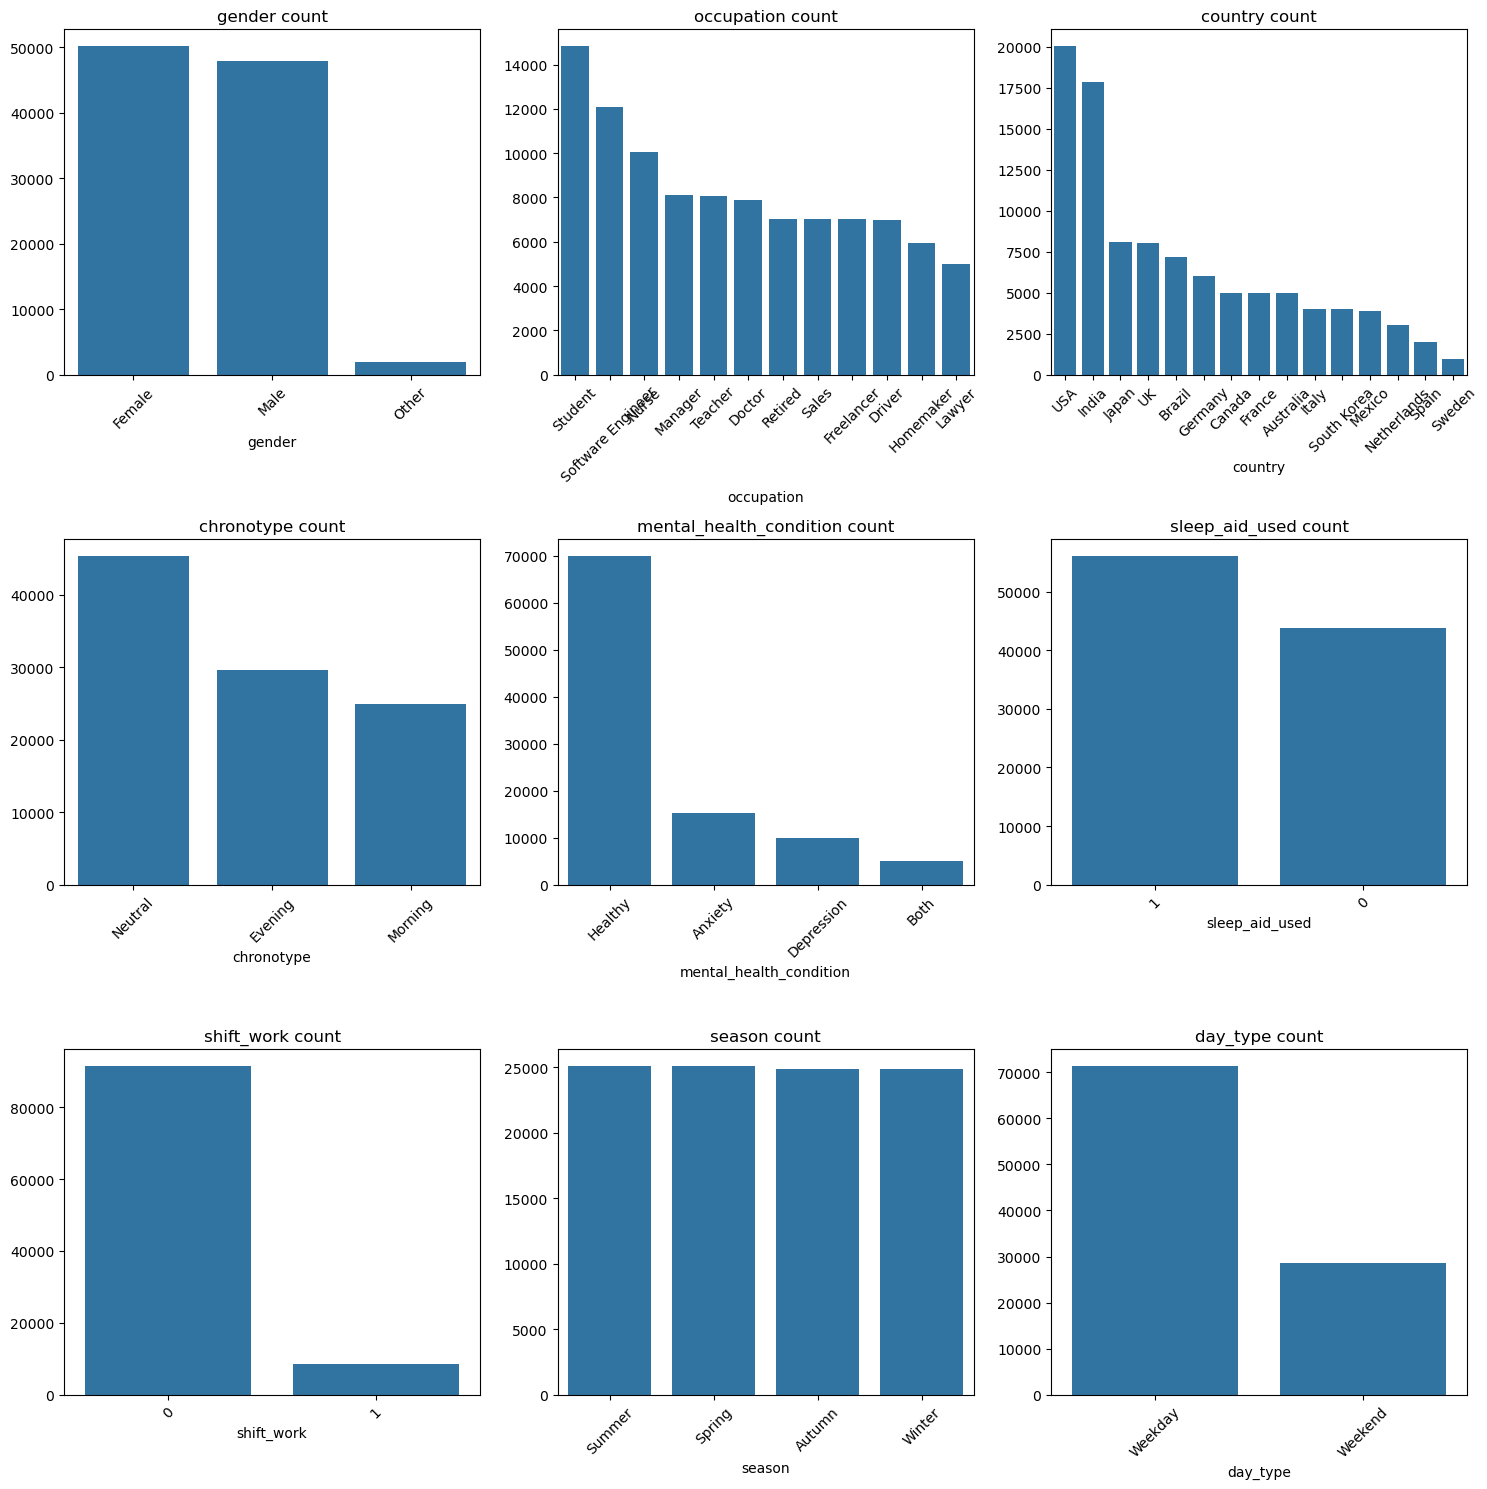

In [22]:
import matplotlib.pyplot as plt
import seaborn as sns
import math

categorical_cols = [
    'gender', 'occupation', 'country', 'chronotype',
    'mental_health_condition', 'sleep_aid_used',
    'shift_work', 'season', 'day_type'
]


# determine grid size
n_cols = 3
n_rows = math.ceil(len(categorical_cols) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 5 * n_rows))
axes = axes.flatten()  # makes indexing easier

for i, col in enumerate(categorical_cols):
    sns.countplot(
        data=data,
        x=col,
        order=data[col].value_counts().index,
        ax=axes[i]
    )
    
    axes[i].set_title(f'{col} count')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('')
    axes[i].tick_params(axis='x', rotation=45)

# remove empty subplots (if any)
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

Categorical features show some notable imbalances, majority of individuals have no mental health condition, very few do shift work, and Other gender is underrepresented, while season is perfectly balanced, occupation is spread across 13 categories with Student being most common, and USA and India dominate the country distribution across 15 countries.